In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
## Step 1: Load and Preprocess Data
# Define transformations for images
transform = transforms.Compose([
    transforms.ToTensor(),          # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize images
])

In [5]:
# Load Fashion-MNIST dataset
train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 208kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.4MB/s]


In [6]:
# Get the shape of the first image in the training dataset
image, label = train_dataset[0]
print(image.shape)
print(len(train_dataset))

torch.Size([1, 28, 28])
60000


In [7]:
# Get the shape of the first image in the test dataset
image, label = test_dataset[0]
print(image.shape)
print(len(test_dataset))

torch.Size([1, 28, 28])
10000


In [8]:
# Create DataLoader for batch processing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [9]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super(CNNClassifier, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*7*7, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu3(x)

        x = self.fc2(x)

        return x

In [10]:
from torchsummary import summary

# Initialize model
model = CNNClassifier()

# Move model to GPU if available
if torch.cuda.is_available():
    device = torch.device("cuda")
    model.to(device)

# Print model summary
print('Name:latchaya priyan S')
print('Register Number:212224230139')
summary(model, input_size=(1, 28, 28))

Name:latchaya priyan S
Register Number:212224230139
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
         MaxPool2d-3           [-1, 32, 14, 14]               0
            Conv2d-4           [-1, 64, 14, 14]          18,496
              ReLU-5           [-1, 64, 14, 14]               0
         MaxPool2d-6             [-1, 64, 7, 7]               0
            Linear-7                  [-1, 128]         401,536
              ReLU-8                  [-1, 128]               0
            Linear-9                   [-1, 10]           1,290
Total params: 421,642
Trainable params: 421,642
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.65
Params size (MB): 1.61
Estimated Total Size (M

In [11]:
# Initialize model, loss function, and optimizer


model = CNNClassifier().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
## Step 3: Train the Model

def train_model(model, train_loader, num_epochs=3):

    model.train()
    print('Name:latchaya priyan S')
    print('Register Number:212224230139')

    for epoch in range(num_epochs):

        running_loss = 0.0

        for images, labels in train_loader:

            if torch.cuda.is_available():
                images = images.to(device)
                labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()


        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

In [13]:
# Train the model
train_model(model, train_loader)

Name:latchaya priyan S
Register Number:212224230139
Epoch [1/3], Loss: 0.4031
Epoch [2/3], Loss: 0.2584
Epoch [3/3], Loss: 0.2136


In [14]:
## Step 4: Test the Model
def test_model(model, test_loader):

    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total

    print('Name: latchaya priyan S')
    print('Register Number: 212224230139')
    print(f'Test Accuracy: {accuracy:.4f}')

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))

    print('Name: latchaya priyan S')
    print('Register Number: 212224230139')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=test_dataset.classes,
                yticklabels=test_dataset.classes)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    # Print classification report
    print('Name: latchaya priyan S')
    print('Register Number: 212224230139')
    print("Classification Report:")

    print(classification_report(all_labels, all_preds,
                                target_names=test_dataset.classes))

Name: latchaya priyan S
Register Number: 212224230139
Test Accuracy: 0.9109
Name: latchaya priyan S
Register Number: 212224230139


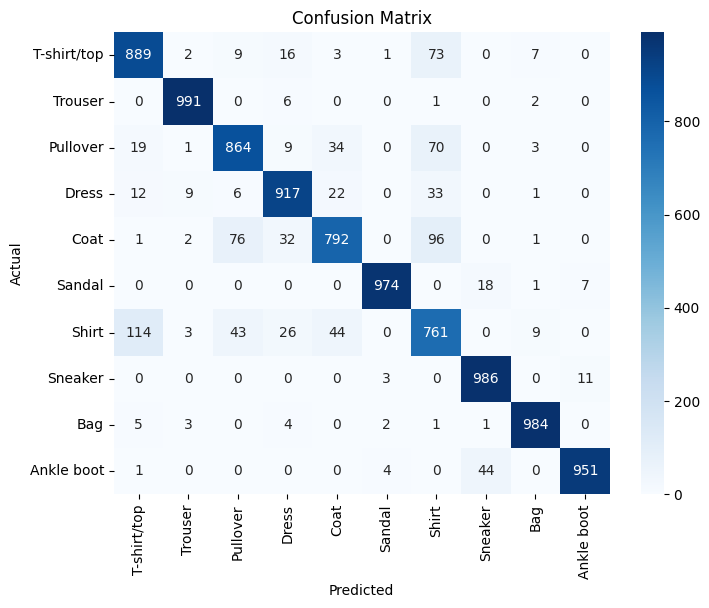

Name: latchaya priyan S
Register Number: 212224230139
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.89      0.87      1000
     Trouser       0.98      0.99      0.99      1000
    Pullover       0.87      0.86      0.86      1000
       Dress       0.91      0.92      0.91      1000
        Coat       0.88      0.79      0.84      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.74      0.76      0.75      1000
     Sneaker       0.94      0.99      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [15]:
# Evaluate the model
test_model(model, test_loader)


In [16]:
def predict_image(model, image_index, dataset):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)   # ensure model is on same device
    model.eval()

    image, label = dataset[image_index]

    image = image.unsqueeze(0).to(device)   # move image to device

    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)

    class_names = dataset.classes

    print("Name: latchaya priyan S")
    print("Register Number: 212224230139")

    plt.imshow(image.cpu().squeeze(), cmap="gray")
    plt.title(f"Actual: {class_names[label]}  |  Predicted: {class_names[predicted.item()]}")
    plt.axis("off")
    plt.show()

    print(f"Actual: {class_names[label]}, Predicted: {class_names[predicted.item()]}")

Name: latchaya priyan S
Register Number: 212224230139


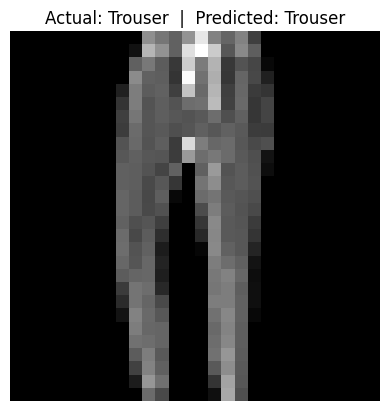

Actual: Trouser, Predicted: Trouser


In [17]:
# Example Prediction
predict_image(model, image_index=80, dataset=test_dataset)